# All About That Phase

## Setup

In [6]:
from IPython.display import Audio 
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.collections as mc
import matplotlib.ticker as mticker

from noFFT_python import resonate_python_phase, resonate_python_phase_frequency
from noFFT_utils import log_frequencies, alphas_heuristic, generate_signal

# Computes values in place at each time for the data buffer
def ewma(data, alphas):
	for i in range(1, len(data)):
		data[i] = (1-alphas) * data[i-1] + alphas * data[i]
	return data


In [7]:
# Geometrically spaced frequencies (log frequency scale)
fmin: float = 32.70
n_freqs: int = 112
freqs_per_octave: int = 12
frequencies = log_frequencies(fmin=fmin, n_freqs=n_freqs, freqs_per_octave=freqs_per_octave)

# print(frequencies)


## Instantaneous Frequency - Single Resonator

(70560, 1) (70560, 1)
(70560, 1)


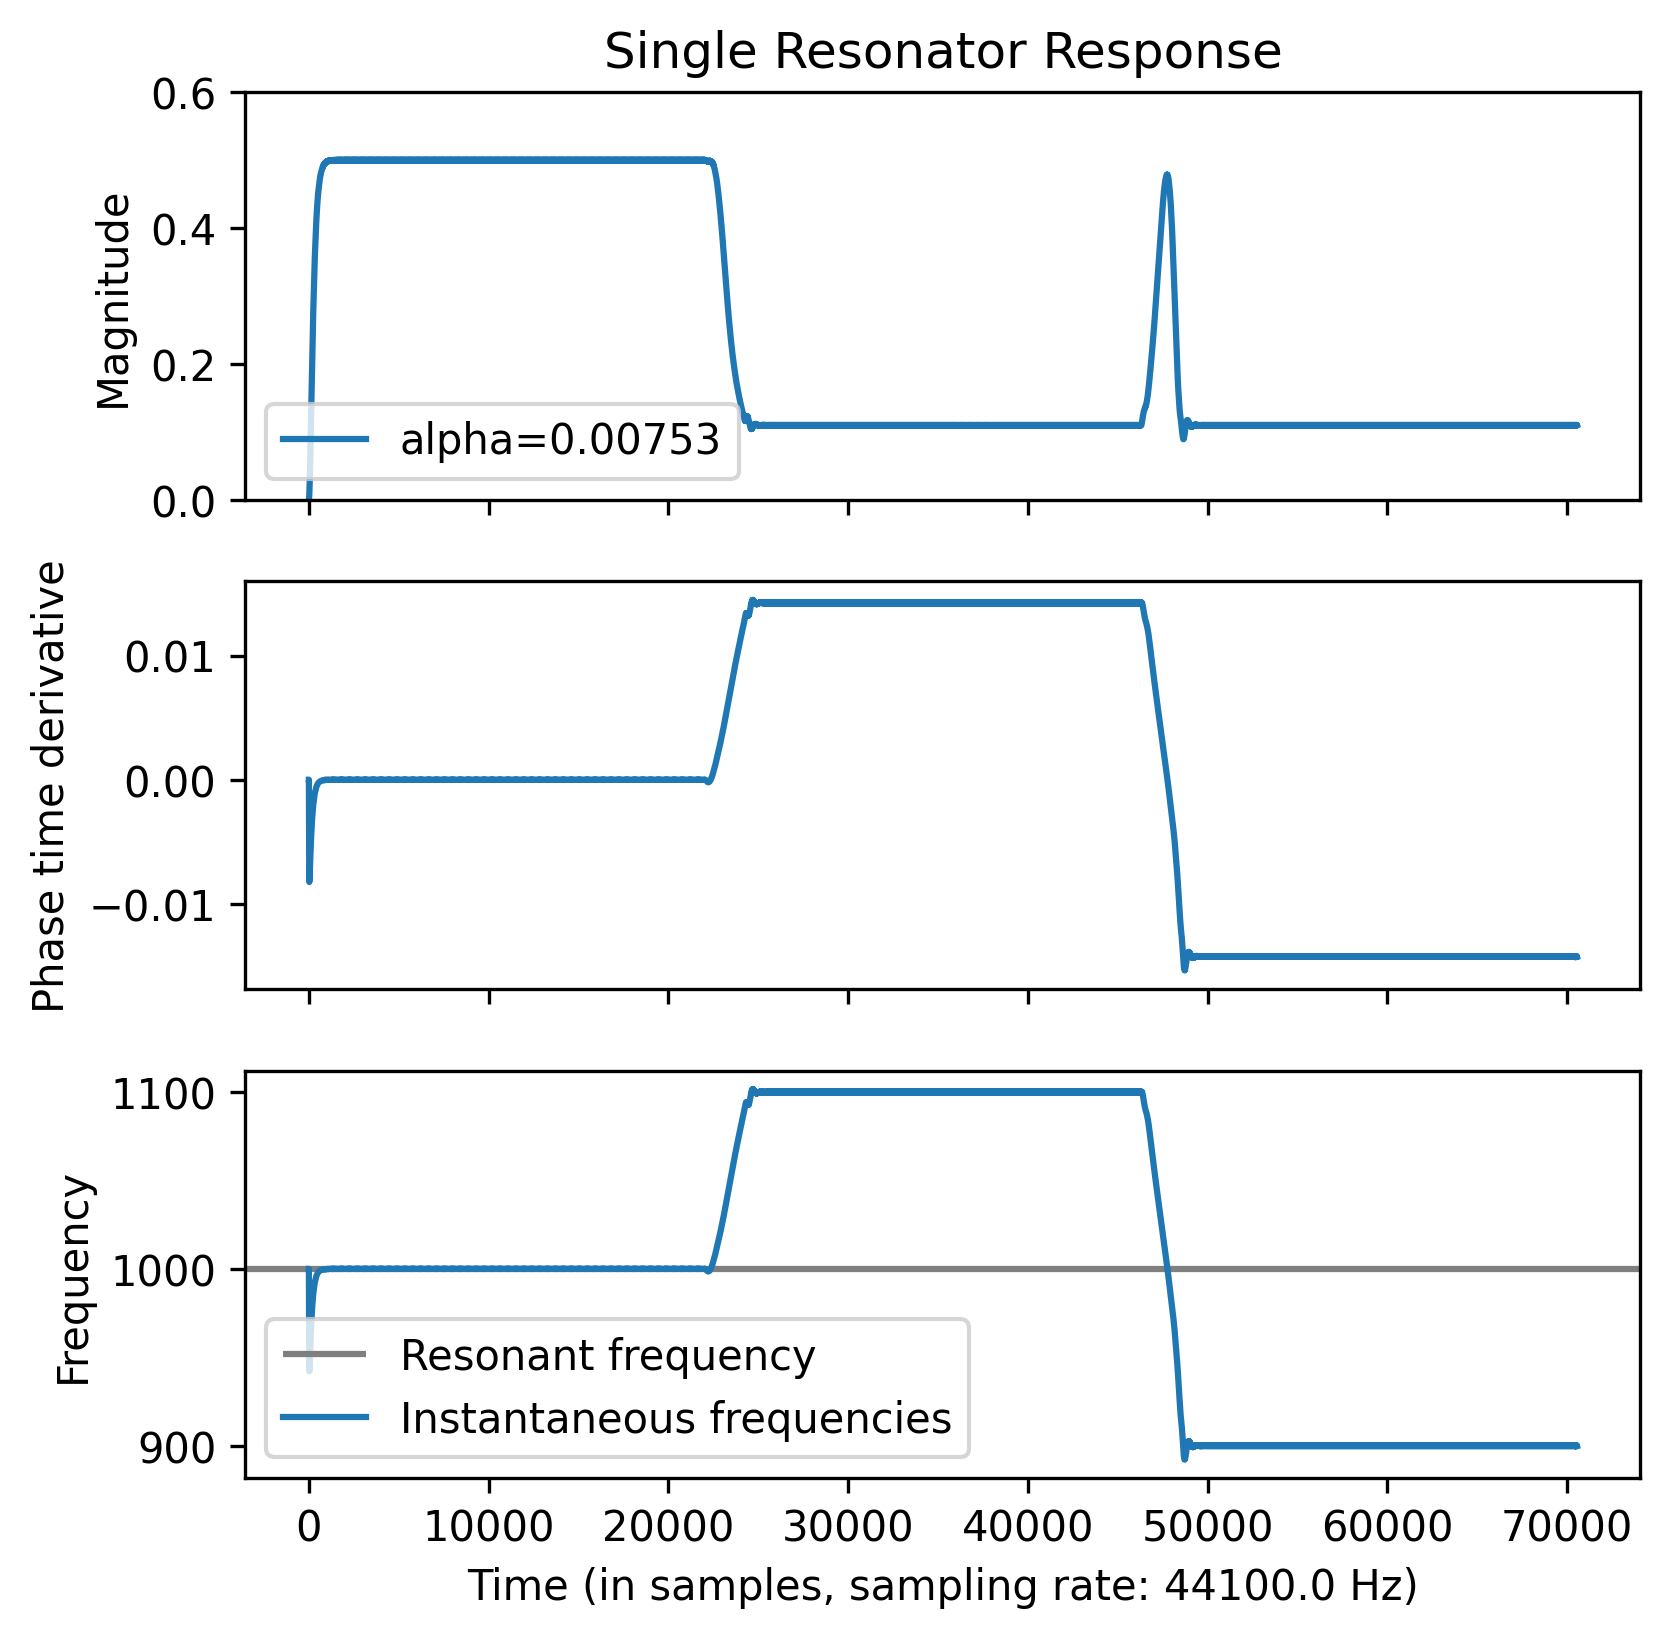

In [8]:
sampling_rate = 44100.0 # in Hz
# duration = 0.1 # in s
# numpoints = int(sampling_rate*duration)

# Resonant frequency
rfreq = 1000
rfreqs = np.array([rfreq])

# heuristic for alpha as a function of frequency and sampling rate
alphas = alphas_heuristic(frequencies=rfreqs, sr=sampling_rate, k=1)

# With smoothing, beta = alpha

# Input frequency (step)
# ifreq = 900

# signal = generate_signal([ifreq], [1.0], [0.0], sr=sampling_rate)
# smoothed_output, conjugate_product = resonate_python_phase_frequency(ifreq=ifreq, rfreqs=rfreqs, alphas=alphas, betas=alphas, sr=sampling_rate, duration=duration)

durations = [0.5, 0.5, 0.5]

# ifreqs = [440.0, 400.0, 480.0]
# ifreqs = [100.0, 110.0, 90.0]
ifreqs = [1000.0, 1100.0, 900.0]
# ifreqs = [10000.0, 11000.0, 9000.0]

signal = generate_signal(ifreqs, durations, transition_duration=0.05, sr=sampling_rate)
numpoints = len(signal) # signal.shape[0]

total_duration = numpoints / sampling_rate
# print(total_duration)

smoothed_output, conjugate_product = resonate_python_phase(signal=signal, rfreqs=rfreqs, alphas=alphas, betas=alphas, duration=total_duration)

print(smoothed_output.shape, conjugate_product.shape)

# smoothed_output = frequency_response(ifreq=ifreq, rfreqs=rfreqs, alphas=alphas, sr=sampling_rate, duration=duration, output_type='complex')
# print(smoothed_output.shape)
# print(smoothed_output)

smoothed_magnitudes = np.abs(smoothed_output)
smoothed_phases = np.angle(smoothed_output)

# Delta Phases

# print(conjugate_product.shape)
# print(conjugate_product)

gammas = alphas

delta_phases = np.angle(conjugate_product)
print(delta_phases.shape)
delta_phases = ewma(delta_phases, gammas)

# Instantaneous Frequencies
insta_freqs = rfreqs + delta_phases * sampling_rate / (2 * np.pi)
# print(rfreqs.shape, delta_phases.shape, insta_freqs.shape)

# fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(8, 6), dpi=300)
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(6, 6), dpi=300)

ax[0].plot(smoothed_magnitudes, label=f"alpha={alphas[0]:.5f}")
ax[0].set(ylim=(0,0.6),
          title=f"Single Resonator Response",
          # xlabel=f"Time (in samples, sampling rate: {sampling_rate} Hz)",
          ylabel='Magnitude')
ax[0].legend()
ax[0].label_outer()

# ax[1].plot(smoothed_phases)
# ax[1].set(ylim=(-3.5,3.5),
#           title=f"Resonant frequency = {frequency} Hz",
#           xlabel=f"Time (in samples, sampling rate: {sampling_rate} Hz",
#           ylabel='Phase')

ax[1].plot(delta_phases)
ax[1].set(#ylim=(-0.01,0.01),
        #   title=f"Resonant frequency = {frequency} Hz",
        #  xlabel=f"Time (in samples, sampling rate: {sampling_rate} Hz)",
          ylabel='Phase time derivative')
ax[1].label_outer()

ax[2].hlines(rfreqs[0], 0, 1, transform=ax[2].get_yaxis_transform(), colors='tab:gray', label='Resonant frequency')
ax[2].plot(insta_freqs, label='Instantaneous frequencies')
ax[2].set(#ylim=(rfreqs[0]-5,rfreqs[0]+5),
        #   title=f"Resonant frequency = {frequency} Hz",
          # yscale='log',
          xlabel=f"Time (in samples, sampling rate: {sampling_rate} Hz)",
          ylabel='Frequency')
ax[2].legend()

plt.show()



In [9]:
sampling_rate = 44100.0 # in Hz
# duration = 0.1 # in s
# numpoints = int(sampling_rate*duration)

# Resonant frequency
rfreq = 1000
rfreqs = np.array([rfreq])

# heuristic for alpha as a function of frequency and sampling rate
alphas = alphas_heuristic(frequencies=rfreqs, sr=sampling_rate, k=1)

# With smoothing, beta = alpha

# Input frequency (step)
# ifreq = 900

# signal = generate_signal([ifreq], [1.0], [0.0], sr=sampling_rate)
# smoothed_output, conjugate_product = resonate_python_phase_frequency(ifreq=ifreq, rfreqs=rfreqs, alphas=alphas, betas=alphas, sr=sampling_rate, duration=duration)

durations = [0.5, 0.5, 0.5]

# ifreqs = [440.0, 400.0, 480.0]
# ifreqs = [100.0, 110.0, 90.0]
ifreqs = [1000.0, 1100.0, 900.0]
# ifreqs = [10000.0, 11000.0, 9000.0]

signal = generate_signal(ifreqs, durations, transition_duration=0.05, sr=sampling_rate)
numpoints = len(signal) # signal.shape[0]

total_duration = numpoints / sampling_rate
# print(total_duration)

smoothed_output, conjugate_product = resonate_python_phase(signal=signal, rfreqs=rfreqs, alphas=alphas, betas=alphas, duration=total_duration)

print(smoothed_output.shape, conjugate_product.shape)

# smoothed_output = frequency_response(ifreq=ifreq, rfreqs=rfreqs, alphas=alphas, sr=sampling_rate, duration=duration, output_type='complex')
# print(smoothed_output.shape)
# print(smoothed_output)

smoothed_magnitudes = np.abs(smoothed_output)
smoothed_phases = np.angle(smoothed_output)

# Delta Phases

# print(conjugate_product.shape)
# print(conjugate_product)

gammas = alphas

delta_phases = np.angle(conjugate_product)
print(delta_phases.shape)
# delta_phases = ewma(delta_phases, gammas)

phases = np.angle(smoothed_output)


for i in range(2,delta_phases.shape[0]):
    if np.sign(delta_phases[i,0]) != np.sign(delta_phases[i-1,0]):
        print(i, phases[i,0], delta_phases[i,0], delta_phases[i-1,0], delta_phases[i-2,0], " | ", delta_phases[i,0] + delta_phases[i-1,0])


(70560, 1) (70560, 1)
(70560, 1)
2 -0.21362309372306348 -0.07114521717312172 -0.0 0.0  |  -0.07114521717312172
30 -1.3712557522697393 0.0009858879610263255 -8.687638825965269e-05 -0.001959503346856078  |  0.0008990115727666729
34 -1.3702681607327374 -0.0012507277479876131 2.1929730629806252e-05 0.0009244130451323666  |  -0.001228798017357807
52 -1.460817453364316 0.0004299338081270998 -0.0001306805717339596 -0.000933114142136007  |  0.00029925323639314023
57 -1.4591311033757126 -0.0004534825709373462 0.00011927990069694383 0.000539914859955561  |  -0.00033420267024040237
74 -1.4975103706417494 0.0003038411071737016 -3.960453763283223e-05 -0.0004993356516396307  |  0.0002642365695408694
79 -1.4956715208191182 -2.299950534239268e-05 0.0002859744946537439 0.0004926240822795382  |  0.00026297498931135123
95 -1.5177788539267154 1.0884228357747955e-05 -0.0002989460062401485 -0.0006564976452319572  |  -0.0002880617778824005
102 -1.5159605822782896 -0.0001458744987583186 0.0001074944981761029 

## Instantaneous Frequencies - Resonator Bank

112 frequencies: 32.7 - 19910.18120222156
(44100, 112) (44100, 112)
(44100, 112)
(112,) (44100, 112) (44100, 112)


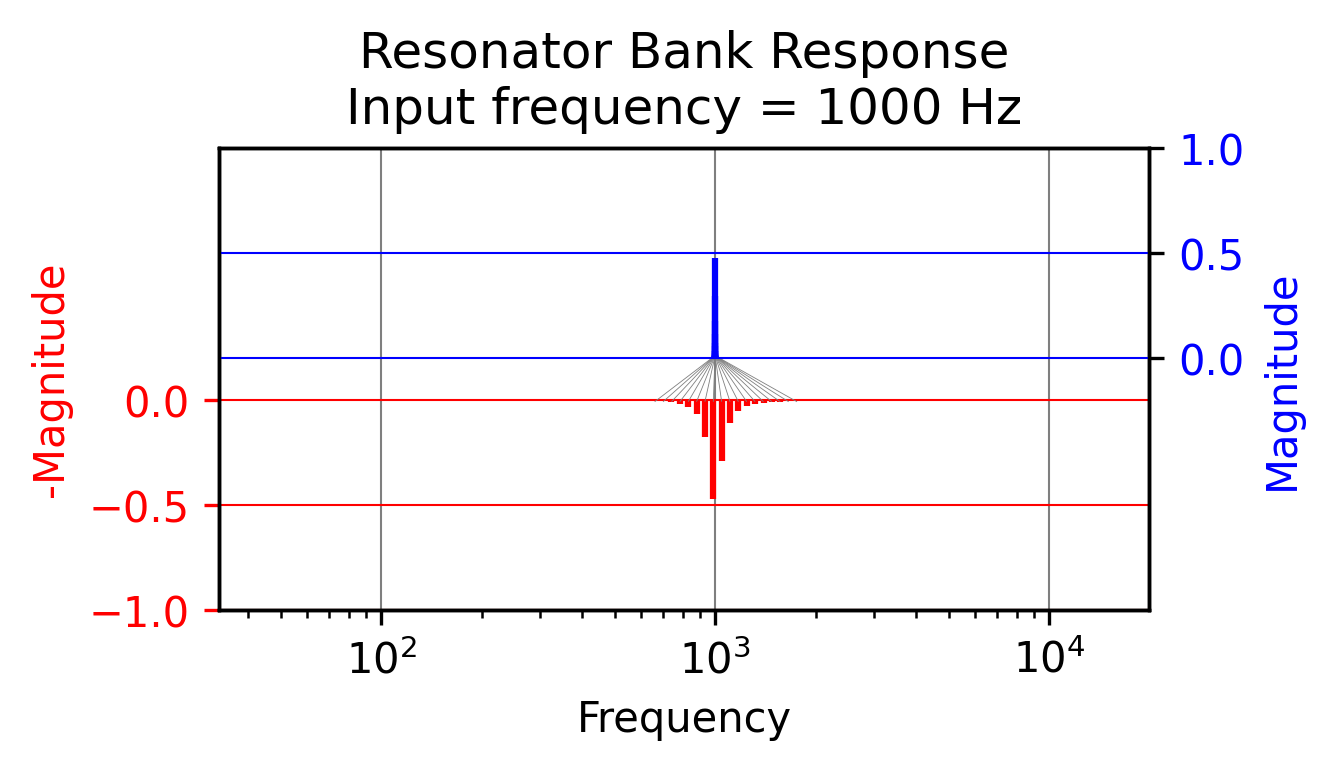

In [ ]:
sampling_rate = 44100.0 # in Hz
duration = 1 # in s

# Resonant frequencies

# Geometrically spaced frequencies (log frequency scale)
fmin: float = 32.70

n_freqs: int = 112
freqs_per_octave: int = 12

# n_freqs: int = 28 # 112
# freqs_per_octave: int = 3 # 12

rfreqs = log_frequencies(fmin=fmin, n_freqs=n_freqs, freqs_per_octave=freqs_per_octave)
print(f"{n_freqs} frequencies: {rfreqs[0]} - {rfreqs[-1]}")

# heuristic for alpha as a function of frequency and sampling rate
alphas = alphas_heuristic(frequencies=rfreqs, sr=sampling_rate, k=1)

# With smoothing, beta = alpha

# Input frequency (step)
ifreq = 1000
signal = generate_signal(frequencies=[ifreq], durations=[duration], transition_duration=0.0, sr=sampling_rate)

# signal = generate_signal(frequencies=[100], durations=[duration], transition_duration=0.0, sr=sampling_rate) + generate_signal(frequencies=[1000], durations=[duration], transition_duration=0.0, sr=sampling_rate) + generate_signal(frequencies=[10000], durations=[duration], transition_duration=0.0, sr=sampling_rate)
# signal = signal / 3

smoothed_output, conjugate_product = resonate_python_phase(signal=signal, rfreqs=rfreqs, alphas=alphas, betas=alphas, duration=duration)

print(smoothed_output.shape, conjugate_product.shape)

# smoothed_output = frequency_response(ifreq=ifreq, rfreqs=rfreqs, alphas=alphas, sr=sampling_rate, duration=duration, output_type='complex')
# print(smoothed_output.shape)
# print(smoothed_output)

smoothed_magnitudes = np.abs(smoothed_output)
smoothed_phases = np.angle(smoothed_output)

# Delta Phases
gammas = alphas

# print(conjugate_product.shape)
# print(conjugate_product)
delta_phases = np.angle(conjugate_product)
print(delta_phases.shape)
delta_phases = ewma(delta_phases, gammas)

# Instantaneous Frequencies
insta_freqs = rfreqs + delta_phases * sampling_rate / (2 * np.pi)
print(rfreqs.shape, delta_phases.shape, insta_freqs.shape)

# ##############

lines = []
for i in range(0, rfreqs.shape[0]):
    if np.abs(smoothed_magnitudes[-1,i]) > 0.005:
        lines.append([(rfreqs[i], -0.1), (insta_freqs[-1,i], 0.1)])

color2='tab:gray'
lc = mc.LineCollection(lines, color=color2, linewidths=0.2)


fig, ax1 = plt.subplots(nrows=1, sharex=True, figsize=(4, 2), dpi=300)

color1='r'
ax1.vlines(rfreqs, np.zeros_like(rfreqs), -smoothed_magnitudes[-1], color=color1, label=f"alpha = beta = {alphas[0]}")
ax1.set(title=f"Resonator Bank Response\nInput frequency = {ifreq} Hz",
        xlabel='Frequency',
        ylabel='-Magnitude',
        xscale='log',
        xlim=(rfreqs[0],rfreqs[-1]),
        ylim=(-0.8,1.2))
ax1.yaxis.label.set_color(color1)
ax1.grid(axis='x', visible=1, color=color2, lw=0.5)
ax1.grid(axis='y', visible=1, color=color1, lw=0.5)
ax1.set_yticks([0.0, -0.5, -1.0])
ax1.tick_params(axis='y', color=color1, labelcolor=color1, grid_color=color1, grid_linewidth=0.5)
# ax1.legend()

ax2 = ax1.twinx()
ax2.add_collection(lc)
ax2.set(ylim=(-1.0,1.0))
ax2.set_yticks([])

color3='b'
ax3 = ax1.twinx()
ax3.vlines(insta_freqs[-1], np.zeros_like(rfreqs), smoothed_magnitudes[-1], color=color3, label=f"alpha = beta = {alphas[0]}")
ax3.set(ylabel='Magnitude',
        ylim=(-1.2,0.8))
ax3.yaxis.label.set_color(color3)
ax3.grid(axis='y', visible=1, color=color3, lw=0.5)
ax3.set_yticks([0.0, 0.5, 1.0])
ax3.tick_params(axis='y', labelcolor=color3, grid_color=color3, grid_linewidth=0.5)
# ax3.legend()

plt.show()




## Frequency Tracking - Single Resonator

In [13]:
sampling_rate = 44100.0 # in Hz
durations = [0.5, 0.5, 0.5]

# ifreqs = [440.0, 400.0, 480.0]
# ifreqs = [100.0, 110.0, 90.0]
ifreqs = [1000.0, 1100.0, 900.0]
# ifreqs = [10000.0, 11000.0, 9000.0]

# signal = generate_signal([110], [1.0], [0.0], sr=sampling_rate)
signal = generate_signal(ifreqs, durations, transition_duration=0.05, sr=sampling_rate)
numpoints = len(signal) # signal.shape[0]

# librosa.display.waveshow(signal, sr=sampling_rate)
Audio(signal, rate=sampling_rate)

dw=-0.14247585730565954 ?== -0.14247585730565954
(70560, 1)
(1,)
-31.68407520010037 18.123488114981484 8.479843083097658e-05


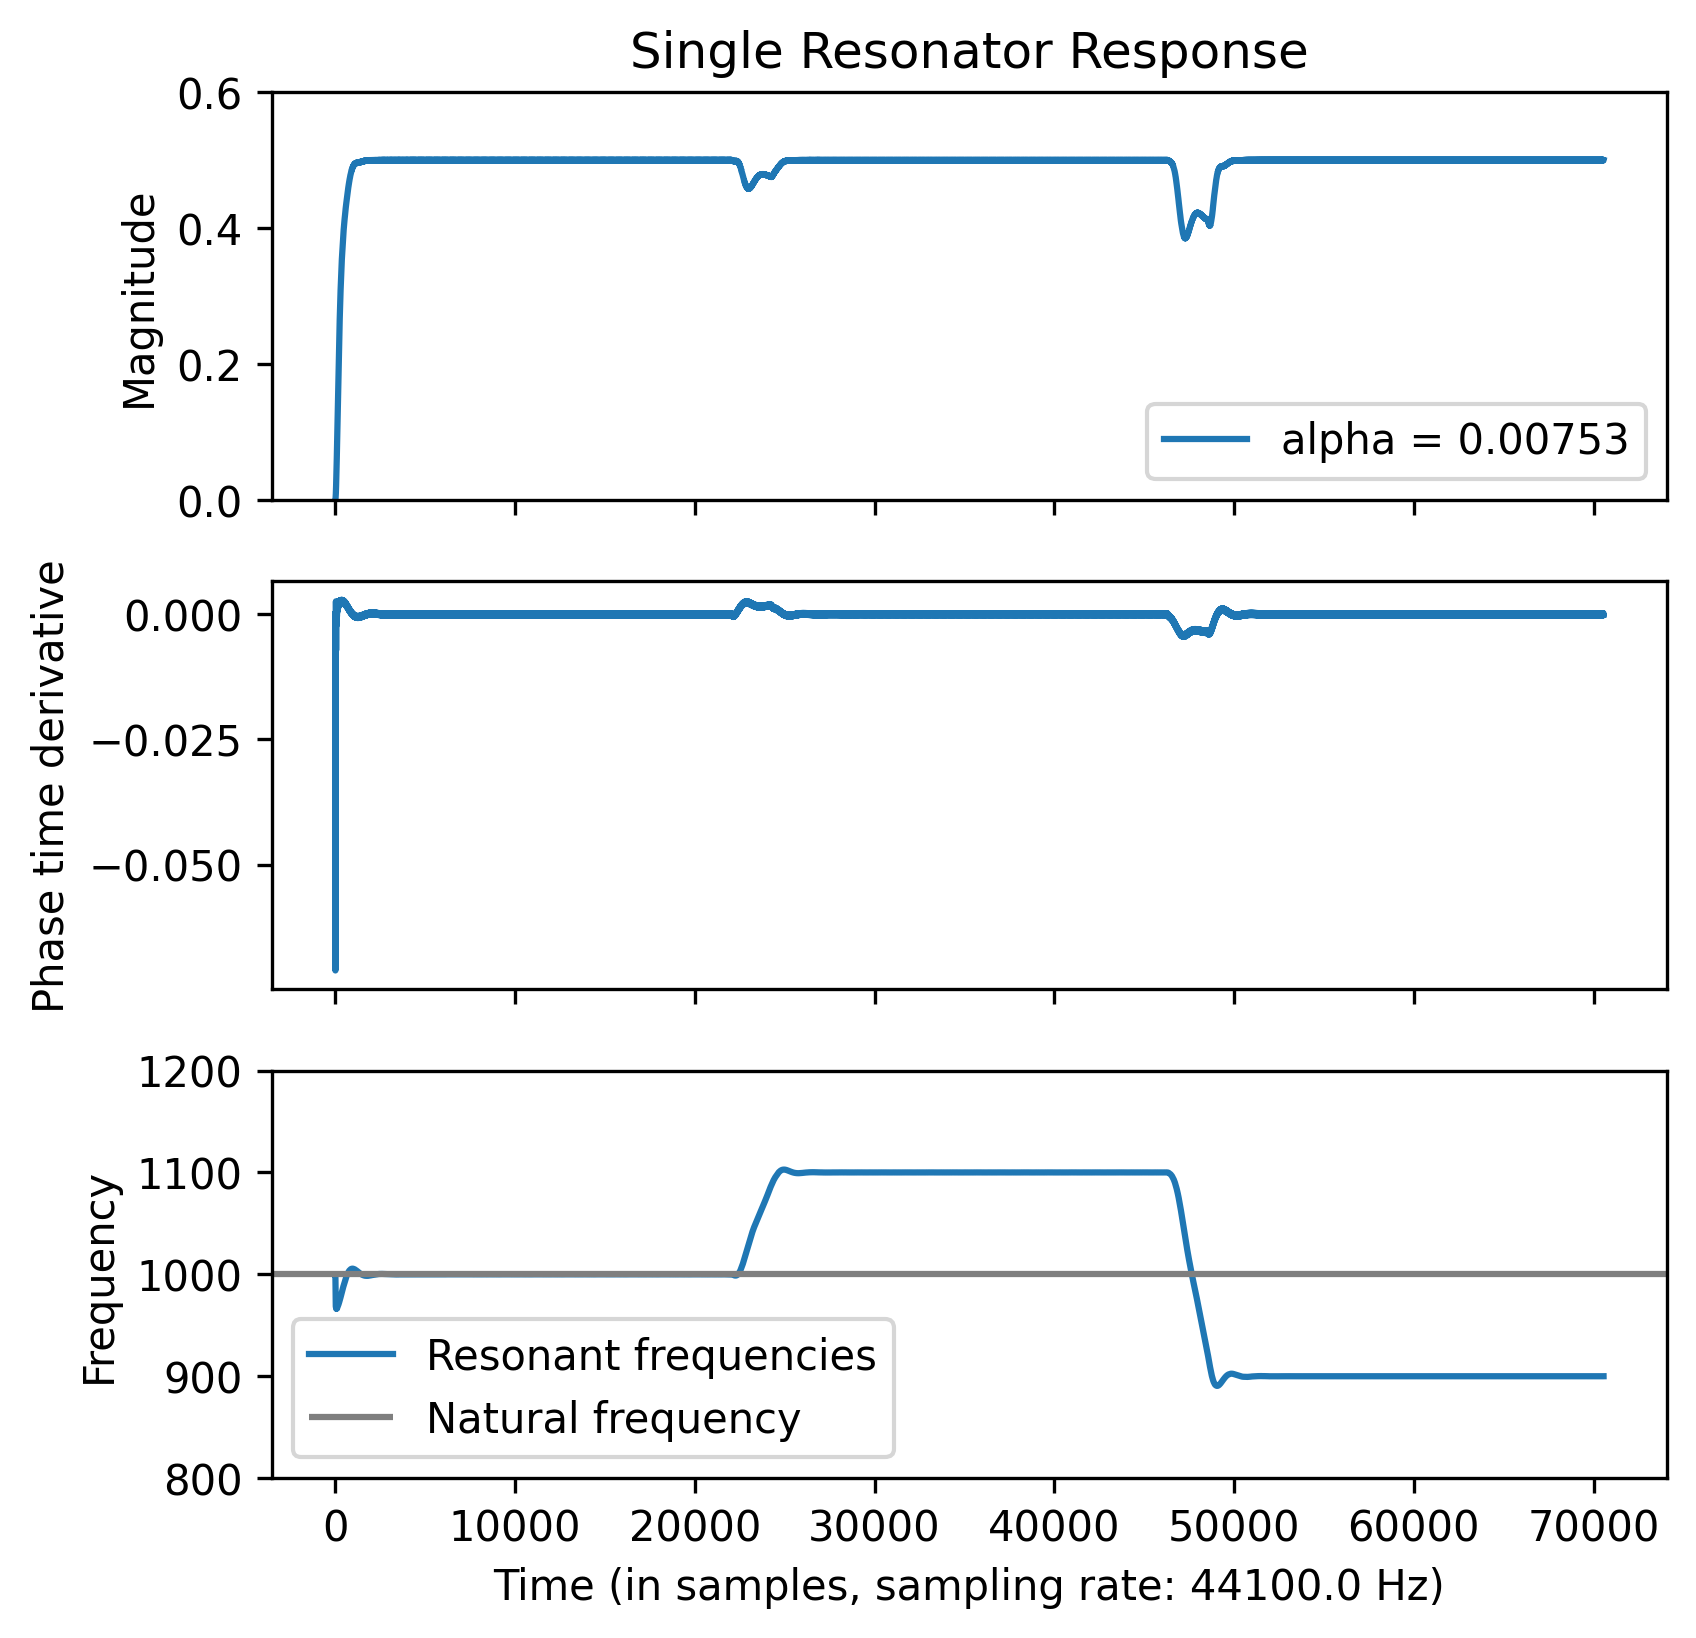

In [14]:
# Natural frequency
# Take the first frequency in signal
nfreq = ifreqs[0]
nfreqs = np.array([nfreq])


# heuristic for alpha as a function of frequency and sampling rate
alphas = alphas_heuristic(frequencies=nfreqs, sr=sampling_rate, k=1)
alpha = alphas[0]

# With smoothing, beta = alpha



# Phasor
dw = -2*np.pi*nfreq/sampling_rate # initial angular velocity
W = np.exp(-1j * dw)
# print(W)

dw2 = -np.angle(W)
print(f"dw={dw} ?== {dw2}")

Z = np.zeros((numpoints, nfreqs.shape[0]), dtype=complex)
Z[0] = 1

print(Z.shape)
print(Z[0].shape)

raw_complex = np.zeros_like(Z)

# smoothed output
smoothed_complex = np.zeros_like(Z)

# conjugate product
conjugate_product = np.ones_like(Z)

delta_phases = np.zeros((numpoints, nfreqs.shape[0]))
delta_frequencies = np.zeros((numpoints, nfreqs.shape[0]))

resonant_frequencies = np.zeros((numpoints, nfreqs.shape[0]))
resonant_frequencies[0] = nfreq
 
oma = 1.0 - alpha

# TODO: don't call this one gamma? Why alpha / 10 works better in Oscillators?
# results with gamma = alpha look better?
sigma = alpha / 2

# only do one loop and compute complex values
for i in range(1, numpoints):
	Z[i] = Z[i-1] * W
	raw_complex[i] = oma * raw_complex[i-1] + alpha * signal[i] * Z[i]
	smoothed_complex[i] = oma * smoothed_complex[i-1] + alpha * raw_complex[i]
	conjugate_product[i] = smoothed_complex[i] * np.conjugate(smoothed_complex[i-1])
	# no need to smoothe the conjugate product itself?
	
	# 3 different ways to compute the frequency adjustment for tracking

	delta_phases[i] = np.angle(conjugate_product[i])
	# delta_phases[i] = (1-gamma) * delta_phases[i-1] + gamma * np.angle(conjugate_product[i])
	delta_frequencies[i] = delta_phases[i] * sampling_rate / (2 * np.pi)

	if True:
		# Explicit frequency computation and back

		# this is the EWMA on resonant_frequencies
		resonant_frequencies[i] = resonant_frequencies[i-1] + sigma * delta_phases[i] * sampling_rate / (2 * np.pi)

		dw = 2 * np.pi * resonant_frequencies[i] / sampling_rate
		W = np.exp(-1j * dw)
		# W = np.cos(dw) - 1j * np.sin(dw) # exp(-i dw)

	if False:
		# Direct dw update - no sampling rate involved
		# still requires angle (atan) and exp computation...
		dw = -np.angle(W)
		dw = dw + sigma * delta_phases[i]
		W = np.exp(-1j * dw)
		# W = np.cos(dw) - 1j * np.sin(dw) # exp(-i dw)
		#  for plotting only...
		resonant_frequencies[i] = resonant_frequencies[i-1] + gamma * delta_phases[i] * sampling_rate / (2 * np.pi)

	if False:
		# Rotate W by - sigma * delta_phases
		# Complex multiplications
		# still requires abs and power...
		mSCP = np.abs(conjugate_product[i])
		nSCP = conjugate_product[i] / mSCP if mSCP > 0 else 1
		# scaling the angle requires taking power
		snSCP = np.power(nSCP, -sigma, dtype=complex)
		W = W * snSCP
		#  for plotting only...
		resonant_frequencies[i] = resonant_frequencies[i-1] + gamma * delta_phases[i] * sampling_rate / (2 * np.pi)

	# print (np.abs(conjugate_product[i]), delta_frequencies[i])
# return smoothed_complex, conjugate_product

print(np.min(delta_frequencies[10000:]), np.max(delta_frequencies[10000:]), np.median(delta_frequencies[10000:]))

smoothed_magnitudes = np.abs(smoothed_complex)

# Delta Phases

# print(conjugate_product.shape)
# print(conjugate_product)
# delta_phases = np.angle(conjugate_product)
# print(delta_phases.shape)
# delta_phases = ewma(delta_phases, alphas/2)

# Instantaneous Frequencies
# insta_freqs = rfreqs + delta_phases * sampling_rate / (2 * np.pi)
# print(rfreqs.shape, delta_phases.shape, insta_freqs.shape)

# fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(8, 6), dpi=300)
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(6, 6), dpi=300)

ax[0].plot(smoothed_magnitudes, label=f"alpha = {alphas[0]:.5f}")
ax[0].set(ylim=(0,0.6),
          title=f"Single Resonator Response",
        #   xlabel=f"Time (in samples, sampling rate: {sampling_rate} Hz",
          ylabel='Magnitude')
ax[0].legend()
ax[0].label_outer()

# ax[1].plot(smoothed_phases)
# ax[1].set(ylim=(-3.5,3.5),
#           title=f"Resonant frequency = {frequency} Hz",
#           xlabel=f"Time (in samples, sampling rate: {sampling_rate} Hz",
#           ylabel='Phase')

ax[1].plot(delta_phases)
ax[1].set(#ylim=(-0.001,0.001),
        #   title=f"Resonant frequency = {frequency} Hz",
        #  xlabel=f"Time (in samples, sampling rate: {sampling_rate} Hz)",
          ylabel='Phase time derivative')
ax[1].label_outer()

ax[2].plot(resonant_frequencies, label='Resonant frequencies')
ax[2].hlines(nfreq, 0, 1, transform=ax[2].get_yaxis_transform(), colors='tab:gray', label='Natural frequency')
ax[2].set(ylim=(nfreq * 0.8, nfreq * 1.2),
        #   title=f"Resonant frequency = {frequency} Hz",
          xlabel=f"Time (in samples, sampling rate: {sampling_rate} Hz)",
          ylabel='Frequency')
ax[2].legend()

plt.show()


## Frequency Tracking - Resonator Bank

In [15]:
default_power_threshold = 0.25 / 10000.0

def resonate_python_tracking(signal, sampling_rate, nfreqs, alphas, betas, power_threshold = default_power_threshold):
    numpoints = len(signal)
    numresonators = len(nfreqs)

    # Phasor
    # Initial angular velocities
    dws = -2*np.pi*nfreqs/sampling_rate # initial angular velocity
    W = np.exp(-1j * dws)
    Z = np.zeros((numpoints, nfreqs.shape[0]), dtype=complex)
    Z[0] = 1

    print(Z.shape)
    print(Z[0].shape)

    raw_complex = np.zeros_like(Z)

    # smoothed output
    smoothed_complex = np.zeros_like(Z)

    # conjugate product
    conjugate_product = np.ones_like(Z)

    delta_phases = np.zeros((numpoints, nfreqs.shape[0]))
    delta_frequencies = np.zeros((numpoints, nfreqs.shape[0]))

    resonant_frequencies = np.zeros((numpoints, nfreqs.shape[0]))
    resonant_frequencies[0] = nfreqs
    
    omas = 1.0 - alphas
    ombs = 1.0 - betas

    gammas = alphas / 2

    # mag_threshold = 0.5 / 100.0
    # power_threshold = 0.25 / 10000.0


    # only do one loop and compute complex values
    for i in range(1, numpoints):
        Z[i] = Z[i-1] * W
        raw_complex[i] = omas * raw_complex[i-1] + alphas * signal[i] * Z[i]
        smoothed_complex[i] = ombs * smoothed_complex[i-1] + betas * raw_complex[i]
        conjugate_product[i] = smoothed_complex[i] * np.conjugate(smoothed_complex[i-1])
        # no need to smoothe the conjugate product itself
        
        # 3 different ways to compute the frequency adjustment for tracking
        # TODO: smoothing here is key - why alpha?
        # only track if magnitude large enough?
        # limit deviation from natural frequency? or constrain between neighbours?

        delta_phases[i] = np.angle(conjugate_product[i])
        delta_frequencies[i] = delta_phases[i] * sampling_rate / (2 * np.pi)

        if True:
            # Explicit frequency computation and back
            # resonant_frequencies[i] = resonant_frequencies[i-1] + gammas * delta_phases[i] * sampling_rate / (2 * np.pi)


            magnitudes = np.abs(smoothed_complex[i])
            powers = magnitudes ** 2

            # fnx = magnitudes[i] > mag_threshold
            # print(fnx)
            # resonant_frequencies[i, fnx] = resonant_frequencies[i-1, fnx] + gammas * delta_phases[i, fnx] * sampling_rate / (2 * np.pi)
            
            n=0
            # if magnitudes[n] > mag_threshold:
            if powers[n] > power_threshold:
                resonant_frequencies[i, n] = resonant_frequencies[i-1, n] + gammas[n] * delta_phases[i, n] * sampling_rate / (2 * np.pi)
                # if resonant_frequencies[i,n] > nfreqs[1]:
                #     resonant_frequencies[i,n] = nfreqs[1]
            else:
                # TODO: is this a source of phase discontinuity?
                resonant_frequencies[i,n] = nfreqs[n]

            for n in range(1,numresonators-1):
                # if magnitudes[n] > mag_threshold:
                if powers[n] > power_threshold:
                    resonant_frequencies[i, n] = resonant_frequencies[i-1, n] + gammas[n] * delta_phases[i, n] * sampling_rate / (2 * np.pi)

                    # if resonant_frequencies[i,n] < nfreqs[n-1]:
                    #     resonant_frequencies[i,n] = nfreqs[n-1]
                    #     # print("Limiting down: ", resonant_frequencies[i,n])

                    # elif resonant_frequencies[i,n] > nfreqs[n+1]:
                    #     resonant_frequencies[i,n] = nfreqs[n+1]
                    #     # print("Limiting up: ", resonant_frequencies[i,n])
                else:
                    resonant_frequencies[i,n] = nfreqs[n]

            # if magnitudes[n] > mag_threshold:
            if powers[n] > power_threshold:
                resonant_frequencies[i, -1] = resonant_frequencies[i-1, -1] + gammas[-1] * delta_phases[i, -1] * sampling_rate / (2 * np.pi)
                # if resonant_frequencies[i,-1] < nfreqs[-2]:
                #     resonant_frequencies[i,-1] = nfreqs[-2]
            else:
                resonant_frequencies[i,-1] = nfreqs[n]

            dw = 2 * np.pi * resonant_frequencies[i] / sampling_rate
            W = np.cos(dw) - 1j * np.sin(dw) # exp(-i dw)

        if False:
            # Direct dw update - no sampling rate involved
            # still requires angle (atan), cos and sin computation...
            dw = -np.angle(W)
            dw = dw + gammas * delta_phases[i]
            W = np.cos(dw) - 1j * np.sin(dw) # exp(-i dw)
            #  for plotting only...
            resonant_frequencies[i] = resonant_frequencies[i-1] + gammas * delta_phases[i] * sampling_rate / (2 * np.pi)

        if False:
            # Rotate W by - alpha * delta_phases
            # Complex multiplications
            # still requires abs and power...
            mSCP = np.abs(conjugate_product[i])
            nSCP = conjugate_product[i] / mSCP if mSCP > 0 else 1
            # scaling the angle requires taking power
            snSCP = np.power(nSCP, -gammas, dtype=complex)
            W = W * snSCP
            #  for plotting only...
            resonant_frequencies[i] = resonant_frequencies[i-1] + gammas * delta_phases[i] * sampling_rate / (2 * np.pi)

    return raw_complex, smoothed_complex, conjugate_product, resonant_frequencies


112 frequencies: 32.7 - 19910.18120222156
(22050, 112)
(112,)
(22050, 112) (22050, 112) (22050, 112)


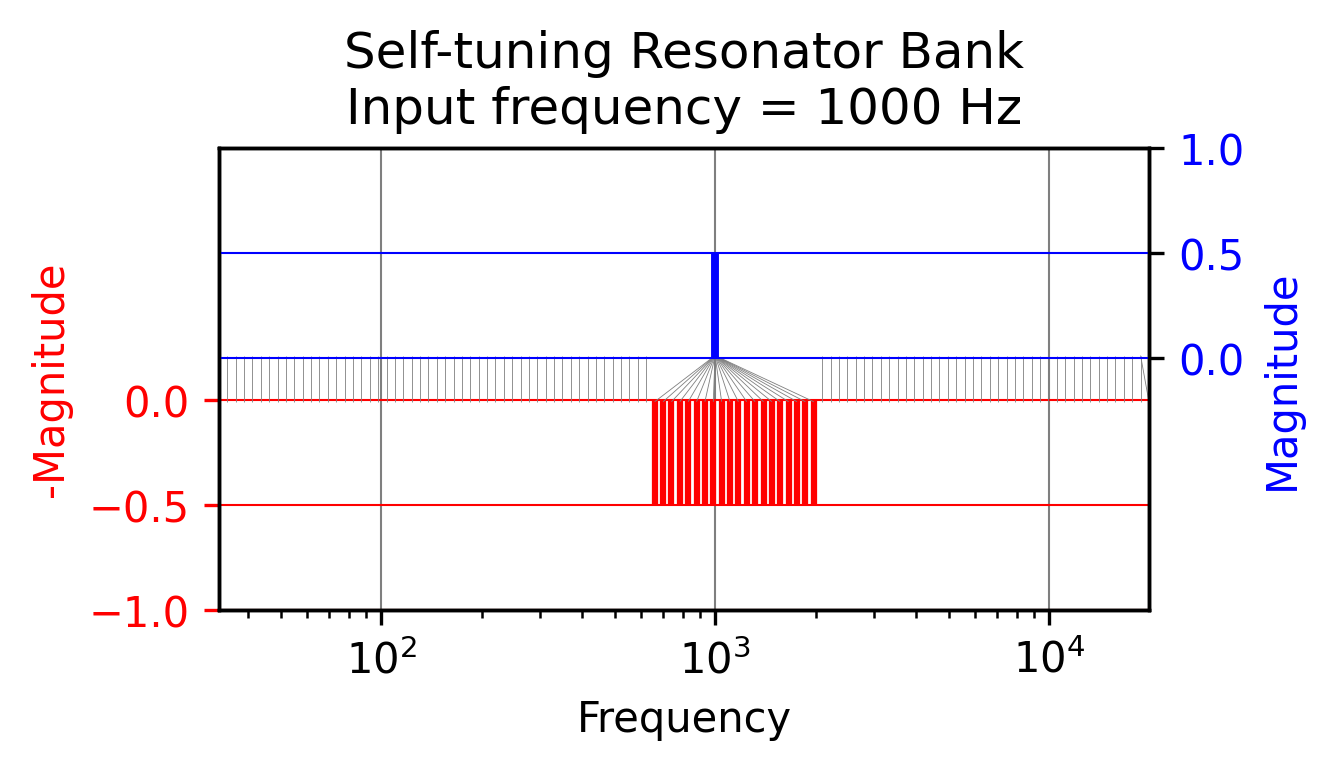

In [16]:
sampling_rate = 44100.0 # in Hz
duration = 0.5 # in s

# Resonant frequencies

# Geometrically spaced frequencies (log frequency scale)
fmin: float = 32.70

nbfreqs: int = 112
freqs_per_octave: int = 12

# nbfreqs: int = 28 # 112
# freqs_per_octave: int = 3 # 12

nfreqs = log_frequencies(fmin=fmin, n_freqs=nbfreqs, freqs_per_octave=freqs_per_octave)
print(f"{nbfreqs} frequencies: {nfreqs[0]} - {nfreqs[-1]}")

# heuristic for alpha as a function of frequency and sampling rate
alphas = alphas_heuristic(frequencies=nfreqs, sr=sampling_rate, k=1)

# With smoothing, beta = alpha

# Input signal (step)
ifreq = 1000
signal = generate_signal(frequencies=[ifreq], durations=[duration], transition_duration=0.0, sr=sampling_rate)

# signal = generate_signal(frequencies=[100], durations=[duration], transition_duration=0.0, sr=sampling_rate) + generate_signal(frequencies=[1000], durations=[duration], transition_duration=0.0, sr=sampling_rate) + generate_signal(frequencies=[10000], durations=[duration], transition_duration=0.0, sr=sampling_rate)
# signal /= 3
# # signal[signal > 1] = 1
# # signal[signal < -1] = -1
# print(np.min(signal), np.max(signal))

raw_output, smoothed_output, conjugate_product, resonant_frequencies = resonate_python_tracking(signal=signal, sampling_rate=sampling_rate, nfreqs=nfreqs, alphas=alphas, betas=alphas)

print(smoothed_output.shape, conjugate_product.shape, resonant_frequencies.shape)

smoothed_magnitudes = np.abs(smoothed_output)

# ##############

lines = []
for i in range(0, nfreqs.shape[0]):
    if np.abs(smoothed_magnitudes[-1,i]) > 0:
        lines.append([(nfreqs[i], -0.1), (resonant_frequencies[-1,i], 0.1)])

color2='tab:gray'
lc = mc.LineCollection(lines, color=color2, linewidths=0.2)


fig, ax1 = plt.subplots(nrows=1, sharex=True, figsize=(4, 2), dpi=300)

color1='r'
ax1.vlines(nfreqs, np.zeros_like(nfreqs), -smoothed_magnitudes[-1], color=color1, label=f"alpha = beta = {alphas[0]}")
# ax1.vlines(nfreqs, np.zeros_like(nfreqs), -1, color=color1, label=f"alpha = beta = {alphas[0]}")
ax1.set(title=f"Self-tuning Resonator Bank\nInput frequency = {ifreq} Hz",
        xlabel='Frequency',
        ylabel='-Magnitude',
        xscale='log',
        xlim=(nfreqs[0],nfreqs[-1]),
        ylim=(-0.8,1.2))
ax1.yaxis.label.set_color(color1)
ax1.grid(axis='x', visible=1, color=color2, lw=0.5)
ax1.grid(axis='y', visible=1, color=color1, lw=0.5)
ax1.set_yticks([0.0, -0.5, -1.0])
ax1.tick_params(axis='y', color=color1, labelcolor=color1, grid_color=color1, grid_linewidth=0.5)
# ax1.legend()

ax2 = ax1.twinx()
ax2.add_collection(lc)
ax2.set(ylim=(-1.0,1.0))
ax2.set_yticks([])

color3='b'
ax3 = ax1.twinx()
ax3.vlines(resonant_frequencies[-1], np.zeros_like(nfreqs), smoothed_magnitudes[-1], color=color3, label=f"alpha = beta = {alphas[0]}")
ax3.set(ylabel='Magnitude',
        ylim=(-1.2,0.8))
ax3.yaxis.label.set_color(color3)
ax3.grid(axis='y', visible=1, color=color3, lw=0.5)
ax3.set_yticks([0.0, 0.5, 1.0])
ax3.tick_params(axis='y', labelcolor=color3, grid_color=color3, grid_linewidth=0.5)
# ax3.legend()

plt.show()




## Tracking Spectrogram

In [17]:
def tracking_spectrogram_old(powers, resonant_frequencies, natural_frequencies, resolution_factor=1):
    """
    resolution_factor: Multiplier for bins per octave. 
    1 = same as input, 2 = double resolution (quarter-tones), etc.
    """
    min_freq = natural_frequencies[0]
    # Adjust bins per octave based on the resolution factor
    num_bins_per_octave = 12 * resolution_factor
    
    num_resonators, num_samples = powers.shape
    # The output height scales by the resolution factor
    num_output_bins = num_resonators * resolution_factor
    spectrogram = np.zeros((num_output_bins, num_samples), dtype=powers.dtype)
    
    # 1. Calculate all bin indices
    safe_freqs = np.where(resonant_frequencies > 0, resonant_frequencies, 1e-5)
    indices = np.round(np.log2(safe_freqs / min_freq) * num_bins_per_octave).astype(int)
    
    # 2. Mask valid ranges
    # Bounds check now uses the new higher bin count
    mask = (resonant_frequencies >= 20.0) & \
           (resonant_frequencies <= 20000.0) & \
           (indices >= 0) & \
           (indices < num_output_bins)
    
    # 3. Aggregate using the high-speed unbuffered maximum
    # We iterate over time slices to handle the 'at' operation efficiently
    for t in range(num_samples):
        valid_mask = mask[:, t]
        if np.any(valid_mask):
            # target_bins: where in the high-res vertical axis the power goes
            target_bins = indices[valid_mask, t]
            # source_powers: the actual power values from the resonators
            source_powers = powers[valid_mask, t]
            
            # np.maximum.at handles cases where multiple resonators fall into
            # the same high-res bin simultaneously by keeping the max.
            np.maximum.at(spectrogram[:, t], target_bins, source_powers)
                
    return spectrogram

In [18]:
def tracking_spectrogram(powers, resonant_frequencies, natural_frequencies, resolution_factor=1):
    """
    Rewritten to resolve overlaps by keeping the power of the resonator 
    whose instantaneous resonant frequency is closest to its natural frequency.
    """
    min_freq = natural_frequencies[0]
    num_bins_per_octave = 12 * resolution_factor
    
    num_resonators, num_samples = powers.shape
    num_output_bins = num_resonators * resolution_factor
    spectrogram = np.zeros((num_output_bins, num_samples), dtype=powers.dtype)
    
    # 1. Calculate all bin indices
    safe_freqs = np.where(resonant_frequencies > 0, resonant_frequencies, 1e-5)
    indices = np.round(np.log2(safe_freqs / min_freq) * num_bins_per_octave).astype(int)
    
    # 2. Calculate the 'Distance to Natural Frequency'
    # We want to minimize this value when multiple resonators hit the same bin.
    # Reshaping natural_frequencies to (N, 1) to broadcast across time (samples)
    dist_to_natural = np.abs(resonant_frequencies - natural_frequencies[:, np.newaxis])
    
    # 3. Mask valid ranges
    mask = (resonant_frequencies >= 20.0) & \
           (resonant_frequencies <= 20000.0) & \
           (indices >= 0) & \
           (indices < num_output_bins)
    
    for t in range(num_samples):
        valid_mask = mask[:, t]
        if not np.any(valid_mask):
            continue
            
        target_bins = indices[valid_mask, t]
        source_powers = powers[valid_mask, t]
        distances = dist_to_natural[valid_mask, t]
        
        # Sort indices by distance (Ascending: smallest error first)
        # When we assign to the spectrogram, the LAST value assigned to a 
        # specific index sticks. So we reverse the sort to put the "best" 
        # resonators at the end of the assignment sequence.
        sort_idx = np.argsort(distances)[::-1] 
        
        # Apply the sorted values
        spectrogram[target_bins[sort_idx], t] = source_powers[sort_idx]
                
    return spectrogram

In [19]:
def tracking_spectrogram_complex(complex_spec, resonant_frequencies, natural_frequencies, resolution_factor=1):
    """
    Inputs:
    - complex_spec: 2D array of complex numbers (resonator outputs)
    - resonant_frequencies: instantaneous frequency of each resonator
    - natural_frequencies: the base frequencies of the resonators
    - resolution_factor: Multiplier for bins per octave
    """
    min_freq = natural_frequencies[0]
    num_bins_per_octave = 12 * resolution_factor
    
    num_resonators, num_samples = complex_spec.shape
    num_output_bins = num_resonators * resolution_factor
    
    # Initialize as complex128 (or complex64) to store phase information
    spectrogram = np.zeros((num_output_bins, num_samples), dtype=complex_spec.dtype)
    
    # 1. Calculate bin indices based on log-frequency scaling
    safe_freqs = np.where(resonant_frequencies > 0, resonant_frequencies, 1e-5)
    indices = np.round(np.log2(safe_freqs / min_freq) * num_bins_per_octave).astype(int)
    
    # 2. Mask valid ranges
    mask = (resonant_frequencies >= 20.0) & \
           (resonant_frequencies <= 20000.0) & \
           (indices >= 0) & \
           (indices < num_output_bins)
    
    # 3. Aggregate using complex addition
    for t in range(num_samples):
        valid_mask = mask[:, t]
        if np.any(valid_mask):
            target_bins = indices[valid_mask, t]
            source_values = complex_spec[valid_mask, t]
            
            # Use np.add.at for complex vector summation.
            # This correctly handles phase interference when multiple 
            # resonators map to the same bin.
            np.add.at(spectrogram[:, t], target_bins, source_values)
                
    return spectrogram

In [20]:
def tracking_spectrogram_proximity(complex_spec, resonant_frequencies, natural_frequencies, resolution_factor=1):
    """
    Aggregates complex values by selecting the resonator whose resonant_frequency
    is closest to its assigned natural_frequency for each target bin.
    """
    min_freq = natural_frequencies[0]
    num_bins_per_octave = 12 * resolution_factor
    
    num_resonators, num_samples = complex_spec.shape
    num_output_bins = num_resonators * resolution_factor
    
    # 1. Calculate the 'tuning error' (proximity)
    # We use the absolute difference between the active frequency and the natural frequency.
    # Lower value = better fit.
    # We expand natural_frequencies to match the shape of resonant_frequencies for calculation.
    tuning_error = np.abs(resonant_frequencies - natural_frequencies[:, np.newaxis])
    
    # Initialize output and a tracker for the "best" (minimum) error seen so far
    spectrogram = np.zeros((num_output_bins, num_samples), dtype=complex_spec.dtype)
    # Initialize with infinity so any real error will be smaller
    min_error_tracker = np.full((num_output_bins, num_samples), np.inf)
    
    # 2. Calculate bin indices
    safe_freqs = np.where(resonant_frequencies > 0, resonant_frequencies, 1e-5)
    indices = np.round(np.log2(safe_freqs / min_freq) * num_bins_per_octave).astype(int)
    
    # 3. Mask valid ranges
    mask = (resonant_frequencies >= 20.0) & \
           (resonant_frequencies <= 20000.0) & \
           (indices >= 0) & \
           (indices < num_output_bins)
    
    # 4. Aggregate by Minimum Error
    for t in range(num_samples):
        valid_mask = mask[:, t]
        if np.any(valid_mask):
            target_bins = indices[valid_mask, t]
            errors = tuning_error[valid_mask, t]
            source_complex = complex_spec[valid_mask, t]
            
            # Iterate through the valid resonators at this time step
            for i, bin_idx in enumerate(target_bins):
                err = errors[i]
                # If this resonator is closer to its natural frequency than 
                # any previous resonator mapped to this bin:
                if err < min_error_tracker[bin_idx, t]:
                    min_error_tracker[bin_idx, t] = err
                    spectrogram[bin_idx, t] = source_complex[i]
                
    return spectrogram

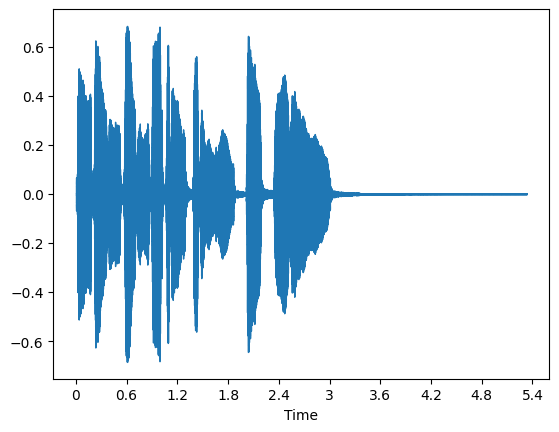

In [23]:
import librosa
import soundfile as sf


# y, sr = sf.read(librosa.ex("pistachio"))

y, sr = sf.read(librosa.ex("trumpet"))
# y, sr = sf.read(librosa.ex("brahms"))
# y, sr = sf.read(librosa.ex("vibeace"))
# y, sr = sf.read(librosa.ex("sweetwaltz"))
# y, sr = sf.read(librosa.ex("libri1"))
# y, sr = sf.read(librosa.ex("libri2"))
# y, sr = sf.read(librosa.ex("libri3"))
# y, sr = sf.read(librosa.ex("robin"))

# print(y.shape)
# print(sr)

librosa.display.waveshow(y, sr=sr)
# print(y.shape)
# print(y.dtype)
Audio(data=y, rate=sr)


frequencies: 32.7 - 3950.680323160497
(117601, 84)
(84,)


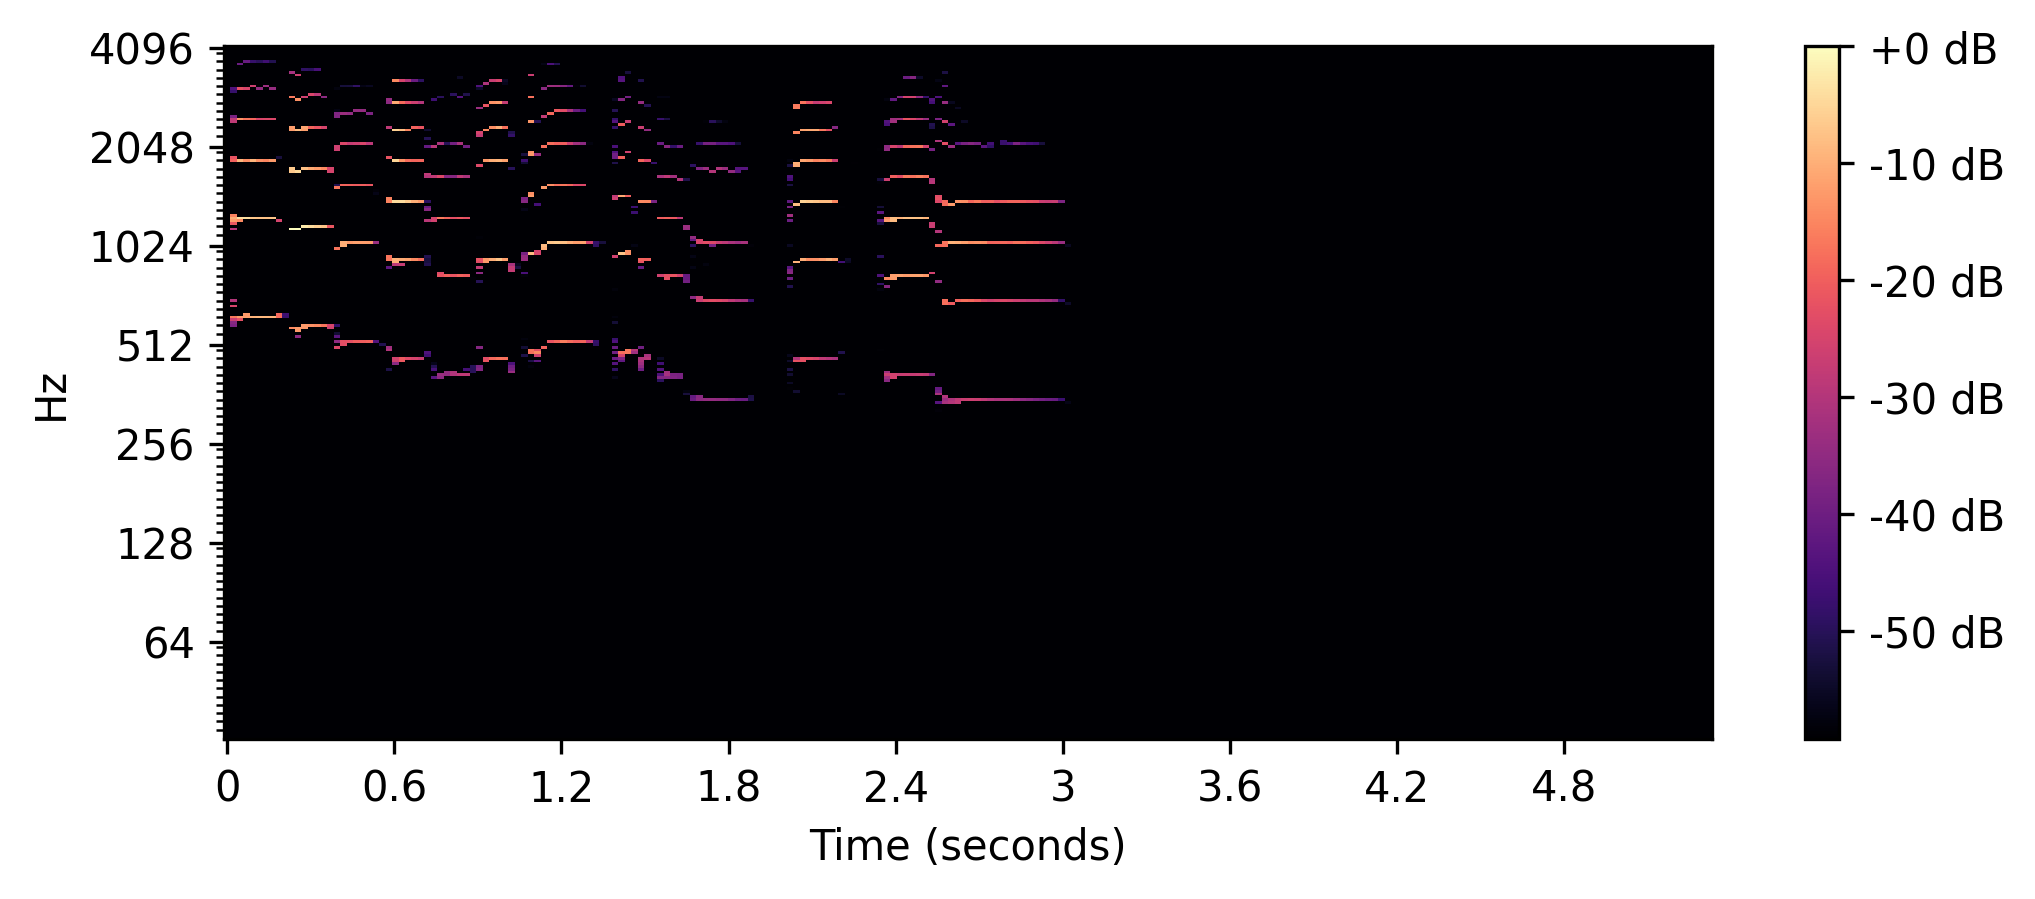

In [24]:
dhl = 512 # hop length for display
minRes = 0 # >= 0
maxRes = 84 # <= 112
power_threshold = 1.0 / 1000000.0
resolution_factor=3
bins_per_octave=resolution_factor * 12
top_db=80

print(f"frequencies: {nfreqs[minRes]} - {nfreqs[maxRes-1]}")

# heuristic for alpha as a function of frequency and sampling rate
alphas = alphas_heuristic(frequencies=nfreqs, sr=sr, k=1)

raw_output, smoothed_output, conjugate_product, resonant_frequencies = resonate_python_tracking(signal=y[:], sampling_rate=sr, nfreqs=nfreqs[minRes:maxRes], alphas=alphas[minRes:maxRes], betas=alphas[minRes:maxRes], power_threshold=power_threshold)

# # compute powers
R_pows = np.abs(smoothed_output.T) ** 2
# print(R_pows.shape, R_pows.dtype)

# # Make a super-resolution tracking spectrogram
ts = tracking_spectrogram(powers=R_pows[:,::dhl], resonant_frequencies=resonant_frequencies.T[:,::dhl], natural_frequencies=nfreqs[minRes:maxRes], resolution_factor=resolution_factor)

# ts = tracking_spectrogram_complex(complex_spec=smoothed_output.T[:,::dhl], resonant_frequencies=resonant_frequencies.T[:,::dhl], natural_frequencies=nfreqs[minRes:maxRes], resolution_factor=resolution_factor)

# ts = tracking_spectrogram_proximity(complex_spec=smoothed_output.T[:,::dhl], resonant_frequencies=resonant_frequencies.T[:,::dhl], natural_frequencies=nfreqs[minRes:maxRes], resolution_factor=resolution_factor)

# print(ts.shape)
R_pows = np.abs(ts) ** 2

R_db = librosa.power_to_db(R_pows, ref=np.max, top_db=top_db)

# Single spectrogram
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
# ax.set(title='Tracking Spectrogram')
img = librosa.display.specshow(
    R_db,
    sr=sr,
    x_axis="s",
    y_axis="cqt_hz",
    fmin = nfreqs[minRes],
    # fmax=nfreqs[maxRes],
    bins_per_octave=bins_per_octave,
    ax=ax
)
fig.colorbar(img, ax=ax, format="%+2.f dB")


## Synthesis

In [25]:
def generate_proximity_synthesis_mask(resonant_frequencies, natural_frequencies, resolution_factor=1):
    """
    Creates a binary mask for resonators. A resonator is 'active' (1) if it is 
    the closest fit to its natural frequency among all resonators competing 
    for the same output frequency bin at that time step.
    """
    num_resonators, num_samples = resonant_frequencies.shape
    num_output_bins = num_resonators * resolution_factor
    min_freq = natural_frequencies[0]
    num_bins_per_octave = 12 * resolution_factor
    
    # 1. Calculate proximity (tuning error)
    # Shape: (num_resonators, num_samples)
    tuning_error = np.abs(resonant_frequencies - natural_frequencies[:, np.newaxis])
    
    # 2. Calculate target bin indices
    safe_freqs = np.where(resonant_frequencies > 0, resonant_frequencies, 1e-5)
    indices = np.round(np.log2(safe_freqs / min_freq) * num_bins_per_octave).astype(int)
    
    # 3. Define validity mask
    valid_range_mask = (resonant_frequencies >= 20.0) & \
                       (resonant_frequencies <= 20000.0) & \
                       (indices >= 0) & \
                       (indices < num_output_bins)
    
    # 4. Initialize the Synthesis Mask and an Error Tracker
    # The error tracker is per-bin, the synthesis_mask is per-resonator
    synthesis_mask = np.zeros((num_resonators, num_samples), dtype=float)
    bin_min_error = np.full((num_output_bins, num_samples), np.inf)
    # Track which resonator ID currently 'owns' the bin
    bin_owner_idx = np.full((num_output_bins, num_samples), -1, dtype=int)
    
    # 5. Populate the winner for each bin
    for t in range(num_samples):
        valid_indices_at_t = np.where(valid_range_mask[:, t])[0]
        
        for res_idx in valid_indices_at_t:
            target_bin = indices[res_idx, t]
            current_error = tuning_error[res_idx, t]
            
            # Check if this resonator is a better fit for this bin than previous ones
            if current_error < bin_min_error[target_bin, t]:
                # If there was a previous owner, we'd theoretically "turn them off"
                # but since we update bin_owner_idx, we can just do one pass at the end
                bin_min_error[target_bin, t] = current_error
                bin_owner_idx[target_bin, t] = res_idx
                
        # Fill the mask for this time step based on the winners
        winners = bin_owner_idx[:, t]
        valid_winners = winners[winners != -1]
        synthesis_mask[valid_winners, t] = 1.0
                
    return synthesis_mask

In [26]:

def generate_proximity_synthesis_mask_vectorized(resonant_frequencies, natural_frequencies, resolution_factor=1):
    num_resonators, num_samples = resonant_frequencies.shape
    num_output_bins = num_resonators * resolution_factor
    min_freq = natural_frequencies[0]
    num_bins_per_octave = 12 * resolution_factor
    
    # 1. Tuning Error: (num_resonators, num_samples)
    tuning_error = np.abs(resonant_frequencies - natural_frequencies[:, np.newaxis])
    
    # 2. Bin Indices: (num_resonators, num_samples)
    safe_freqs = np.clip(resonant_frequencies, 1e-5, 20000.0)
    indices = np.round(np.log2(safe_freqs / min_freq) * num_bins_per_octave).astype(int)
    
    # 3. Validity Mask
    valid_mask = (resonant_frequencies >= 20.0) & (resonant_frequencies <= 20000.0) & \
                 (indices >= 0) & (indices < num_output_bins)

    # 4. Prepare for Vectorized "Winner" Selection
    # To handle 'invalid' resonators, we set their error to infinity
    inf_error = np.full_like(tuning_error, np.inf)
    masked_errors = np.where(valid_mask, tuning_error, inf_error)
    
    # We need to map (resonator, time) -> (bin, time)
    # Since multiple resonators map to one bin, we create a 3D volume or 
    # use a trick with flat indices to find the minimum.
    synthesis_mask = np.zeros((num_resonators, num_samples))
    
    for t in range(num_samples):
        # We still have a time loop here, but we vectorize the RESONATOR selection.
        # This is usually 100x faster than the double loop.
        bins_at_t = indices[:, t]
        errors_at_t = masked_errors[:, t]
        
        # Sort by bin then by error
        # This identifies which resonator has the minimum error for each bin
        order = np.lexsort((errors_at_t, bins_at_t))
        sorted_bins = bins_at_t[order]
        
        # Find the first occurrence of each bin in the sorted list (the one with min error)
        _, unique_indices = np.unique(sorted_bins, return_index=True)
        
        # Only keep indices that aren't pointing to an Inf error
        winning_res_indices = order[unique_indices]
        valid_winners = winning_res_indices[errors_at_t[winning_res_indices] != np.inf]
        
        synthesis_mask[valid_winners, t] = 1.0
        
    return synthesis_mask

In [27]:
def generate_proximity_mask_threshold(resonant_frequencies, natural_frequencies, threshold_octaves=1/12):
    """
    Suppresses redundant resonators based on a frequency proximity threshold.
    If two resonators are within 'threshold_octaves', the one with the 
    lower tuning error is kept.
    """
    num_resonators, num_samples = resonant_frequencies.shape
    tuning_error = np.abs(resonant_frequencies - natural_frequencies[:, np.newaxis])
    
    synthesis_mask = np.zeros_like(resonant_frequencies)
    
    # Convert frequencies to log-space (octaves) for easy distance calculation
    # We use a small epsilon to avoid log(0)
    log_freqs = np.log2(np.maximum(resonant_frequencies, 1e-5))

    for t in range(num_samples):
        # 1. Get frequencies and errors for this slice
        freqs_t = log_freqs[:, t]
        errors_t = tuning_error[:, t]
        
        # 2. Filter out invalid/silent frequencies (e.g., < 20Hz)
        valid_indices = np.where(resonant_frequencies[:, t] >= 20.0)[0]
        if len(valid_indices) == 0:
            continue
            
        # 3. Sort valid resonators by error (best fit first)
        # This is the "greedy" part: best fits get first pick of the spectrum
        sorted_indices = valid_indices[np.argsort(errors_t[valid_indices])]
        
        active_log_freqs = []
        
        for idx in sorted_indices:
            current_f = freqs_t[idx]
            
            # 4. Check if this frequency is too close to any already-accepted resonator
            is_too_close = False
            for accepted_f in active_log_freqs:
                if abs(current_f - accepted_f) < threshold_octaves:
                    is_too_close = True
                    break
            
            # 5. If it's unique enough, keep it
            if not is_too_close:
                synthesis_mask[idx, t] = 1.0
                active_log_freqs.append(current_f)
                
    return synthesis_mask

In [28]:
def generate_proximity_mask_optimized(resonant_frequencies, natural_frequencies, threshold_octaves=1/12):
    num_resonators, num_samples = resonant_frequencies.shape
    tuning_error = np.abs(resonant_frequencies - natural_frequencies[:, np.newaxis])
    
    # Pre-calculate log frequencies
    log_freqs = np.log2(np.maximum(resonant_frequencies, 1e-5))
    synthesis_mask = np.zeros_like(resonant_frequencies)

    for t in range(num_samples):
        f_t = log_freqs[:, t]
        err_t = tuning_error[:, t]
        
        # 1. Filter out inactive resonators
        valid_indices = np.where(resonant_frequencies[:, t] >= 20.0)[0]
        if len(valid_indices) == 0: continue
        
        # 2. Sort indices by error (lowest error first)
        sorted_indices = valid_indices[np.argsort(err_t[valid_indices])]
        
        # 3. Use a boolean array to keep track of 'available' frequency space
        # We start with all valid ones available
        available = np.ones(len(sorted_indices), dtype=bool)
        
        for i in range(len(sorted_indices)):
            if not available[i]:
                continue
            
            idx = sorted_indices[i]
            synthesis_mask[idx, t] = 1.0
            
            # 4. Vectorized Suppression: 
            # Find all other resonators in the sorted list that are too close to this one
            dist = np.abs(f_t[sorted_indices] - f_t[idx])
            
            # Mark them as unavailable so they can't be picked in later iterations
            # This 'mutes' neighbors within the threshold
            available[dist < threshold_octaves] = False
                
    return synthesis_mask

In [29]:
def generate_proximity_mask_hysteresis(resonant_frequencies, natural_frequencies, 
                                      threshold_octaves=1/12, bias=0.1):
    """
    Greedy proximity mask with temporal hysteresis.
    'bias' reduces the error of resonators that were active in the previous 
    time step, preventing rapid switching (chattering).
    """
    num_resonators, num_samples = resonant_frequencies.shape
    tuning_error = np.abs(resonant_frequencies - natural_frequencies[:, np.newaxis])
    log_freqs = np.log2(np.maximum(resonant_frequencies, 1e-5))
    
    synthesis_mask = np.zeros_like(resonant_frequencies)
    last_mask = np.zeros(num_resonators) # Tracks who was active at t-1

    for t in range(num_samples):
        f_t = log_freqs[:, t]
        
        # Apply Hysteresis: 
        # Reduce the error of resonators that were on in the last frame.
        # This makes it 'harder' for a new resonator to kick an old one out.
        err_t = tuning_error[:, t] - (last_mask * bias * tuning_error[:, t])
        
        valid_indices = np.where(resonant_frequencies[:, t] >= 20.0)[0]
        if len(valid_indices) == 0:
            last_mask[:] = 0
            continue
        
        # Sort by biased error
        sorted_indices = valid_indices[np.argsort(err_t[valid_indices])]
        available = np.ones(len(sorted_indices), dtype=bool)
        
        current_mask_t = np.zeros(num_resonators)
        
        for i in range(len(sorted_indices)):
            if not available[i]:
                continue
            
            idx = sorted_indices[i]
            current_mask_t[idx] = 1.0
            
            # Vectorized suppression of neighbors
            dist = np.abs(f_t[sorted_indices] - f_t[idx])
            available[dist < threshold_octaves] = False
        
        synthesis_mask[:, t] = current_mask_t
        last_mask = current_mask_t # Update for next time step
                
    return synthesis_mask

numpoints: 117601
frequencies: 84
linsp: (117601, 84)
Omegas: (117601, 84)
Px: (117601, 84)
Outputs: (117601,)
-0.23386952873369674 0.27435703098845104
-0.5837083088797929 0.6847599148750305


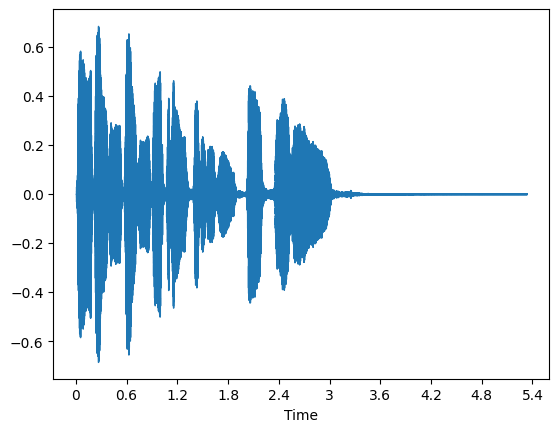

In [31]:
from scipy.ndimage import uniform_filter1d

numpoints = smoothed_output.shape[0]
numfrequencies = smoothed_output.shape[1]
print("numpoints:", numpoints)
print("frequencies:", numfrequencies)

# Phasor values
start = np.zeros(numfrequencies)
stop = (numpoints / sr) * np.ones(numfrequencies)
linsp = np.linspace(start=start, stop=stop, num=numpoints)
print("linsp:", linsp.shape)

targetSR = sr
freqshift = 0.89 # 1.0 is no shift, 1.06 (0.94) is up (down) one semi-tone, 1.12 (0.89) is up (down) one tone

# freqshift = np.linspace(start=1.2*np.ones(numfrequencies), stop=0.8*np.ones(numfrequencies), num=numpoints)

if True:
    # Angular velocities per Delta-T
    dw = 2*np.pi*freqshift*resonant_frequencies/targetSR

    # omegas = np.zeros_like(resonant_frequencies)
    # for i in range(1,numpoints):
    #     omegas[i,:] = omegas[i-1,:] + dw[i,:]

    # Accumulate phase over time
    omegas = np.cumsum(dw, axis=0)
    print("Omegas:", omegas.shape)

    Px = np.exp(1j * omegas)
    print("Px:", Px.shape)

    # tval = tracking_spectrogram_complex(complex_spec=smoothed_output.T, resonant_frequencies=resonant_frequencies.T, natural_frequencies=nfreqs[minRes:maxRes], resolution_factor=1)
    # tval = tracking_spectrogram_proximity(smoothed_output.T, resonant_frequencies=resonant_frequencies.T, natural_frequencies=nfreqs[minRes:maxRes], resolution_factor=1)
    # Kx = tval.T * Px

    # Generate the Mask
    # mask_raw = generate_proximity_synthesis_mask_vectorized(
    #     resonant_frequencies=resonant_frequencies.T, 
    #     natural_frequencies=nfreqs[minRes:maxRes], 
    #     resolution_factor=1
    # ).T

    # mask_raw = generate_proximity_mask_optimized(
    #     resonant_frequencies=resonant_frequencies.T, 
    #     natural_frequencies=nfreqs[minRes:maxRes],
    #     threshold_octaves=1/12).T

    mask_raw = generate_proximity_mask_hysteresis(
        resonant_frequencies.T, 
        nfreqs[minRes:maxRes], 
        threshold_octaves=1/12, 
        bias=0.15
    ).T

    # Smooth the transitions to stop the "clicking"
    # A 10ms window is usually enough to hide phase discontinuities
    fade_len = int(0.010 * targetSR)
    mask_smoothed = uniform_filter1d(mask_raw, size=fade_len, axis=0)

    Kx = smoothed_output * mask_smoothed * Px

    outputs = np.sum(np.real(Kx[:,:]), axis=-1)
    print("Outputs:", outputs.shape)

# Normalize powers to input power range
print(np.min(outputs), np.max(outputs))
outputs = outputs / max(np.max(outputs), -np.min(outputs)) * max(np.max(y), -np.min(y))
print(np.min(outputs), np.max(outputs))

librosa.display.waveshow(outputs, sr=targetSR)

filename = f"../audiofiles/synthesis/synthesized-usm-f{freqshift}-sr{int(targetSR)}.wav"
sf.write(file=filename, data=outputs[..., np.newaxis], samplerate=int(targetSR)) # writing wave file in .wav format

Audio(data=outputs, rate=targetSR, normalize=False)


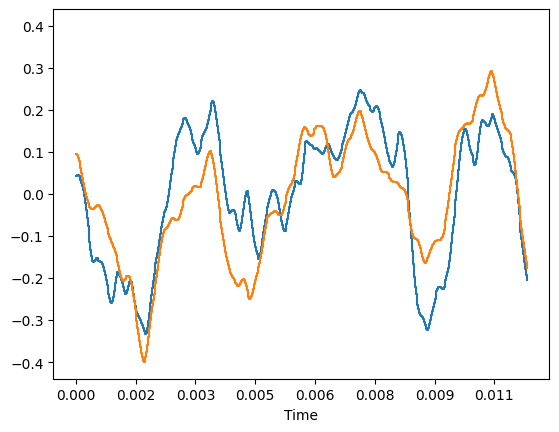

In [125]:
librosa.display.waveshow(y[150100:150600], sr=sr)

librosa.display.waveshow(outputs[150100:150600], sr=sr)
